# Perform NicheNet Analysis Starting from an AnnData Object: Step-by-Step Analysis

In this notebook, you can learn how to perform a basic NicheNet analysis on an AnnData object containing single-cell expression data. The steps of this notebook can also be adapted for other single-cell or bulk frameworks.

**Assuming you have captured the changes in gene expression resulting from your cell-cell communication (CCC) process of interest,** a NicheNet analysis can help you to generate hypotheses about the CCC process. Specifically, NicheNet can predict 1) which ligands from the microenvironment or cell population(s) ("sender/niche") are most likely to affect target gene expression in an interacting cell population ("receiver/target") and 2) which specific target genes are affected by which of these predicted ligands.

As example expression data of interacting cells, we will use mouse NICHE-seq data to explore intercellular communication in the T cell area in the inguinal lymph node before and 72 hours after lymphocytic choriomeningitis virus (LCMV) infection (Medaglia et al., 2017). We will focus on CD8 T cells as the receiver population, and as this dataset contains two conditions (before and after LCMV infection), the differentially expressed genes between these two conditions in CD8 T cells will be used as our gene set of interest. We will then prioritize which ligands from the microenvironment (sender-agnostic approach) and from specific immune cell populations like monocytes, dendritic cells, NK cells, B cells, and CD4 T cells (sender-focused approach) can regulate and induce these observed gene expression changes.

## Prepare NicheNet Analysis

### Load packages and set up data directory

In [31]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

import nichenetr as nn

### Read in the expression data of interacting cells

We load a processed AnnData object (the Python equivalent of the Seurat object from the original vignette). Note that genes should be named by their official mouse/human gene symbol.

In [2]:
adata = nn.load_seurat_obj()
adata

AnnData object with n_obs × n_vars = 5027 × 13541
    obs: 'nGene', 'nUMI', 'orig.ident', 'aggregate', 'res.0.6', 'celltype', 'nCount_RNA', 'nFeature_RNA'
    obsm: 'X_cca', 'X_cca_aligned', 'X_pca', 'X_tsne'
    layers: 'data'

In [3]:
# Convert gene aliases to official symbols
adata = nn.alias_to_symbol_anndata(adata, "mouse")

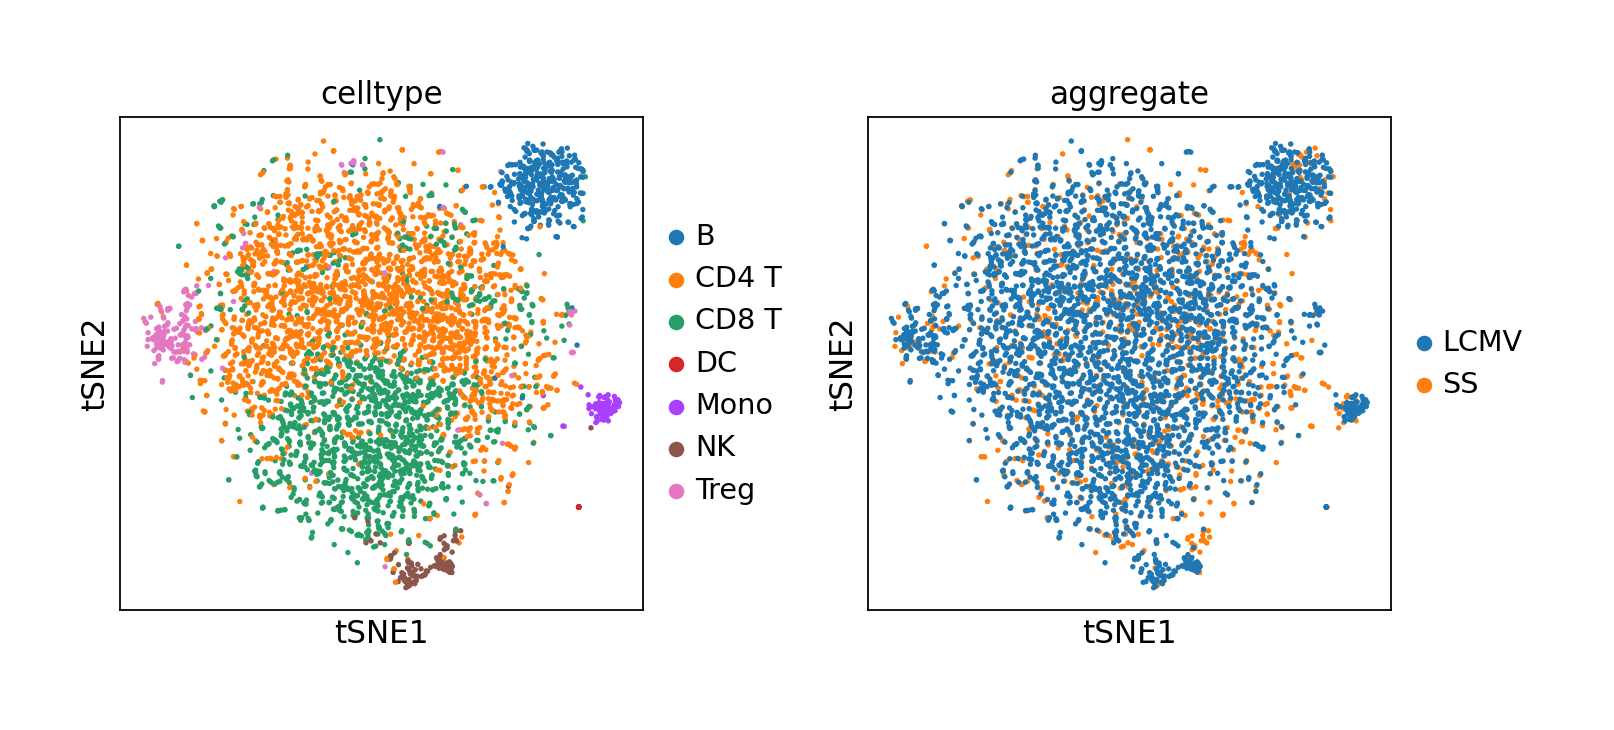

In [4]:
# Visualize cell populations
sc.set_figure_params(figsize=(4, 4))
sc.pl.tsne(adata, color=["celltype", "aggregate"], wspace=.3)

### Read in NicheNet's networks

The ligand-target prior model, ligand-receptor network, and weighted integrated networks are needed. The ligand-target prior model is a matrix describing the potential that a ligand may regulate a target gene. The ligand-receptor network contains information on potential ligand-receptor bindings. The weighted ligand-receptor network contains weights representing the potential that a ligand will bind to a receptor.

In [5]:
organism = "mouse"

lr_network = nn.load_lr_network(organism)
ligand_target_matrix = nn.load_ligand_target_matrix(organism)
weighted_networks = nn.load_weighted_networks(organism)

In [6]:
# Keep distinct ligand-receptor pairs
lr_network = lr_network[["from", "to"]].drop_duplicates()
lr_network.head()

,from,to
0,2300002M23Rik,Ddr1
1,2610528A11Rik,Gpr15
2,9530003J23Rik,Itgal
3,a,Atrn
4,a,F11r


In [7]:
# Inspect the ligand-target matrix
print(f"Ligand-target matrix shape: {ligand_target_matrix.data.shape}")
print(f"Number of target genes (rows): {len(ligand_target_matrix.rownames)}")
print(f"Number of ligands (cols): {len(ligand_target_matrix.colnames)}")

Ligand-target matrix shape: (22521, 1287)
Number of target genes (rows): 22521
Number of ligands (cols): 1287


In [8]:
# Inspect weighted networks
print("\nlr_sig network:")
print(weighted_networks["lr_sig"].head())
print("\ngr network:")
print(weighted_networks["gr"].head())


lr_sig network:
            from      to    weight
0  0610010F05Rik     App  0.109896
1  0610010F05Rik     Cat  0.067324
2  0610010F05Rik    H1f2  0.066010
3  0610010F05Rik  Lrrc49  0.082884
4  0610010F05Rik   Nicn1  0.086396

gr network:
            from             to    weight
0  0610010K14Rik  0610010K14Rik  0.120670
1  0610010K14Rik  2510039O18Rik  0.120596
2  0610010K14Rik  2610021A01Rik  0.025641
3  0610010K14Rik  9130401M01Rik  0.026292
4  0610010K14Rik           Alg1  0.127445


## Perform the NicheNet Analysis

We now recommend users to run both the "sender-agnostic" approach and "sender-focused" approach. These approaches only affect the list of potential ligands that are considered for prioritization.

### 1. Define a set of potential ligands

We first define a "receiver/target" cell population and determine which genes are expressed. Here, we consider a gene to be expressed if it is expressed in at least 5% of cells. The receiver cell population is CD8 T cells.

In [9]:
receiver = "CD8 T"
expressed_genes_receiver = nn.get_expressed_genes(
    adata, celltype_col="celltype", celltype=receiver, pct=0.05
)
print(f"Number of expressed genes in receiver: {len(expressed_genes_receiver)}")

Number of expressed genes in receiver: 3903


In [10]:
# Get expressed receptors and define potential ligands (sender-agnostic)
all_receptors = lr_network["to"].unique().tolist()
expressed_receptors = list(set(all_receptors) & set(expressed_genes_receiver))

potential_ligands = (
    lr_network[lr_network["to"].isin(expressed_receptors)]["from"]
    .unique()
    .tolist()
)
print(f"Number of potential ligands (sender-agnostic): {len(potential_ligands)}")

Number of potential ligands (sender-agnostic): 483


In [11]:
# Sender-focused: define sender cell types and their expressed genes
sender_celltypes = ["CD4 T", "Treg", "Mono", "NK", "B", "DC"]

expressed_genes_sender = set()
for ct in sender_celltypes:
    genes = nn.get_expressed_genes(adata, celltype_col="celltype", celltype=ct, pct=0.05)
    expressed_genes_sender.update(genes)
expressed_genes_sender = list(expressed_genes_sender)

# Filter potential ligands to those expressed in sender cells
potential_ligands_focused = list(set(potential_ligands) & set(expressed_genes_sender))

print(f"Expressed genes in senders: {len(expressed_genes_sender)}")
print(f"Potential ligands (agnostic): {len(potential_ligands)}")
print(f"Potential ligands (sender-focused): {len(potential_ligands_focused)}")

Expressed genes in senders: 8492
Potential ligands (agnostic): 483
Potential ligands (sender-focused): 127


### 2. Define the gene set of interest

The gene set of interest are the differentially expressed (DE) genes between the two conditions in the receiver cell type. The condition of interest is 'LCMV', the reference condition is 'SS'. We use Scanpy's Wilcoxon test for differential expression.

In [15]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [16]:
condition_oi = "LCMV"
condition_reference = "SS"

# Subset to receiver cells
receiver_mask = adata.obs["celltype"] == receiver
adata_receiver = adata[receiver_mask].copy()

# Run DE analysis
sc.tl.rank_genes_groups(
    adata_receiver,
    groupby="aggregate",
    groups=[condition_oi],
    reference=condition_reference,
    method="wilcoxon",
)

de_table = sc.get.rank_genes_groups_df(adata_receiver, group=condition_oi)
de_table = de_table.rename(columns={"names": "gene", "logfoldchanges": "avg_log2FC", "pvals_adj": "p_val_adj"})

# Filter DE genes
geneset_oi = de_table[
    (de_table["p_val_adj"] <= 0.05) & (de_table["avg_log2FC"].abs() >= 0.25)
]["gene"].tolist()

# Keep only genes in the ligand-target matrix
geneset_oi = [g for g in geneset_oi if g in ligand_target_matrix.rownames]
print(f"Number of DE genes in gene set: {len(geneset_oi)}")

Number of DE genes in gene set: 246


### 3. Define the background genes

All expressed genes in the receiver cell population (that are also in the ligand-target matrix) form the background set.

In [17]:
background_expressed_genes = [
    g for g in expressed_genes_receiver if g in ligand_target_matrix.rownames
]

print(f"Background expressed genes: {len(background_expressed_genes)}")
print(f"Gene set of interest: {len(geneset_oi)}")

Background expressed genes: 3476
Gene set of interest: 246


### 4. Perform NicheNet ligand activity analysis

This is the main step of NicheNet where the potential ligands are ranked based on the presence of their target genes in the gene set of interest. Ligands are ranked by the area under the precision-recall curve (AUPR).

We first show the results of the **sender-agnostic** approach.

In [18]:
ligand_activities = nn.predict_ligand_activities(
    geneset=geneset_oi,
    background_expressed_genes=background_expressed_genes,
    ligand_target_matrix=ligand_target_matrix,
    potential_ligands=potential_ligands,
)

ligand_activities = ligand_activities.sort_values("aupr_corrected", ascending=False)
ligand_activities["rank"] = ligand_activities["aupr_corrected"].rank(ascending=False)
ligand_activities.head(30)

,test_ligand,auroc,aupr,aupr_corrected,pearson,rank
260,Ifna1,0.705221,0.397678,0.326907,0.473725,1.0
274,Ifnb1,0.709802,0.364863,0.294092,0.415682,2.0
279,Ifnl3,0.667348,0.351115,0.280344,0.403032,3.0
301,Il27,0.660455,0.336028,0.265257,0.399405,4.0
276,Ifng,0.722061,0.331488,0.260717,0.407892,5.0
277,Ifnk,0.653494,0.243701,0.172930,0.238291,6.0
275,Ifne,0.651146,0.240318,0.169547,0.251346,7.0
157,Ebi3,0.645723,0.231384,0.160613,0.225343,8.0
278,Ifnl2,0.641587,0.219610,0.148839,0.216403,9.0
267,Ifna2,0.653468,0.214154,0.143383,0.189186,10.0


In [20]:
# Select top 30 ligands
best_upstream_ligands = (
    ligand_activities.nlargest(30, "aupr_corrected")["test_ligand"].tolist()
)

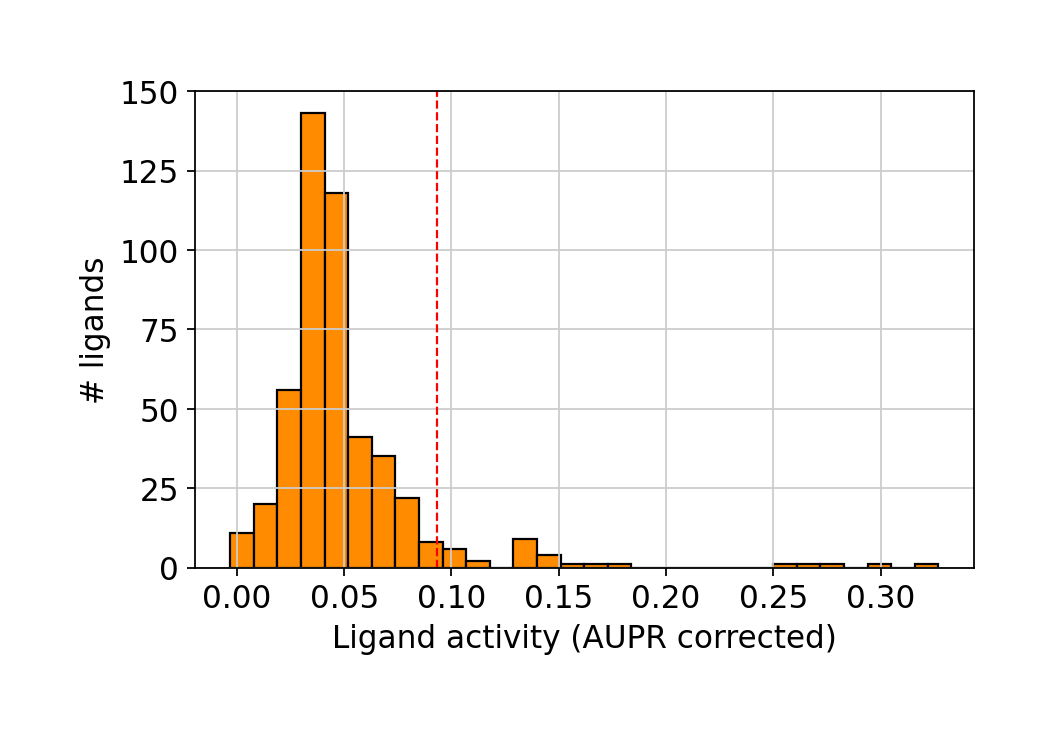

In [21]:
# Ligand activity histogram
cutoff_30 = ligand_activities.nlargest(30, "aupr_corrected")["aupr_corrected"].min()

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(ligand_activities["aupr_corrected"], bins=30, color="darkorange", edgecolor="black")
ax.axvline(cutoff_30, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Ligand activity (AUPR corrected)")
ax.set_ylabel("# ligands")
plt.tight_layout()
plt.show()

In [32]:
sns.set_style('ticks')

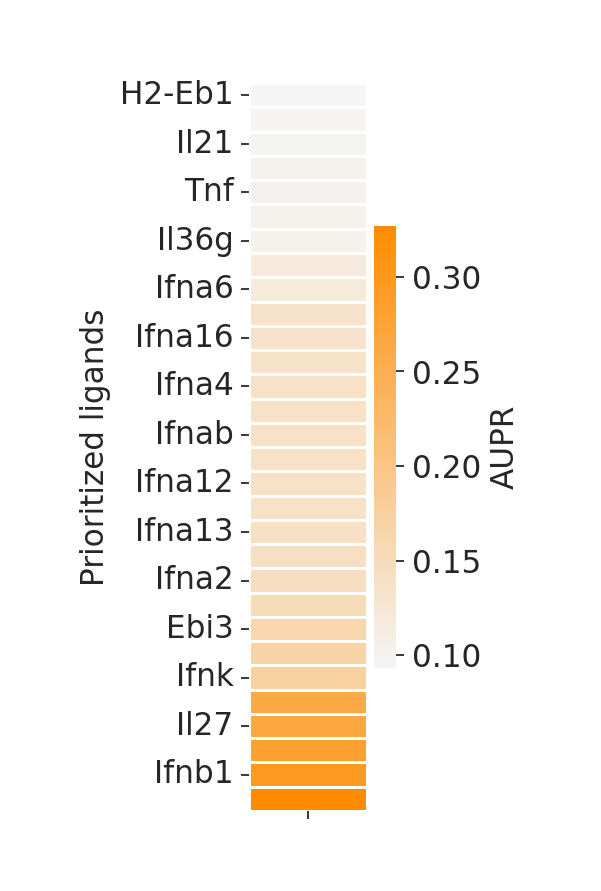

In [33]:
# Visualize ligand activity of top 30 ligands as a heatmap
vis_ligand_aupr = (
    ligand_activities[ligand_activities["test_ligand"].isin(best_upstream_ligands)]
    .set_index("test_ligand")[["aupr_corrected"]]
    .sort_values("aupr_corrected")
)

_ = nn.make_heatmap_ggplot(
    vis_ligand_aupr,
    y_name="Prioritized ligands",
    x_name="Ligand activity",
    legend_title="AUPR",
    color="darkorange",
    x_axis=False,
    figsize=(3, 5),
    show=True,
)

### 5. Infer target genes and receptors of top-ranked ligands

#### Active target gene inference

Active target genes are genes in the gene set of interest that have the highest regulatory potential for each top-ranked ligand.

In [25]:
# Get weighted ligand-target links for all top ligands
active_ligand_target_links_df = pd.concat(
    [
        nn.get_weighted_ligand_target_links(
            ligand_oi=lig,
            geneset=geneset_oi,
            ligand_target_matrix=ligand_target_matrix,
            n=100,
        )
        for lig in best_upstream_ligands
    ],
    ignore_index=True,
).dropna()

print(f"Number of ligand-target links: {len(active_ligand_target_links_df)}")
active_ligand_target_links_df.head()

Number of ligand-target links: 570


,ligand,target,weight
0,Ifna1,Cnp,0.196279
1,Ifna1,Ddx58,0.246772
2,Ifna1,Eif2ak2,0.245763
3,Ifna1,Gbp2,0.192107
4,Ifna1,Gbp7,0.194638


In [26]:
# Prepare visualization matrix with cutoff
active_ligand_target_links = nn.prepare_ligand_target_visualization(
    ligand_target_df=active_ligand_target_links_df,
    ligand_target_matrix=ligand_target_matrix,
    cutoff=0.33,
)

# The returned array has .rownames (targets) and .colnames (ligands)
order_ligands = [l for l in reversed(best_upstream_ligands) if l in active_ligand_target_links.colnames]
order_targets = [
    t for t in active_ligand_target_links_df["target"].unique()
    if t in active_ligand_target_links.rownames
]

# Build visualization DataFrame (ligands as rows, targets as columns)
df_full = pd.DataFrame(
    active_ligand_target_links,
    index=active_ligand_target_links.rownames,
    columns=active_ligand_target_links.colnames,
)
vis_ligand_target = df_full.loc[order_targets, order_ligands].T

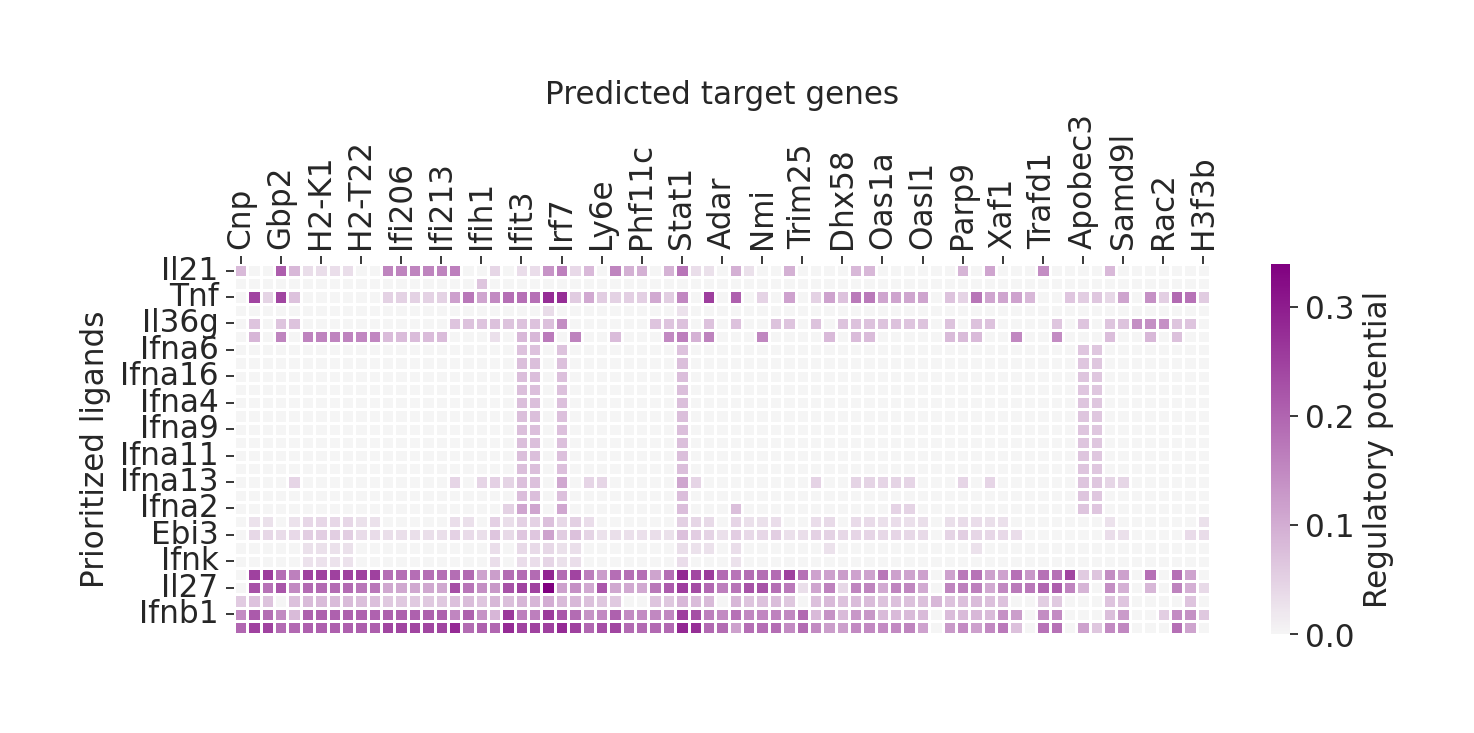

In [34]:
_ = nn.make_heatmap_ggplot(
    vis_ligand_target,
    y_name="Prioritized ligands",
    x_name="Predicted target genes",
    color="purple",
    legend_title="Regulatory potential",
    figsize=(9, 4),
    show=True,
)

#### Receptors of top-ranked ligands

We identify which receptors have the highest interaction potential with the top-ranked ligands.

In [35]:
ligand_receptor_links_df = nn.get_weighted_ligand_receptor_links(
    best_upstream_ligands, expressed_receptors, lr_network, weighted_networks["lr_sig"]
)

vis_ligand_receptor_network = nn.prepare_ligand_receptor_visualization(
    ligand_receptor_links_df, best_upstream_ligands, order_hclust="both"
)

# Transpose: ligands as rows, receptors as columns
df_lr = pd.DataFrame(
    vis_ligand_receptor_network,
    index=vis_ligand_receptor_network.rownames,
    columns=vis_ligand_receptor_network.colnames,
).T

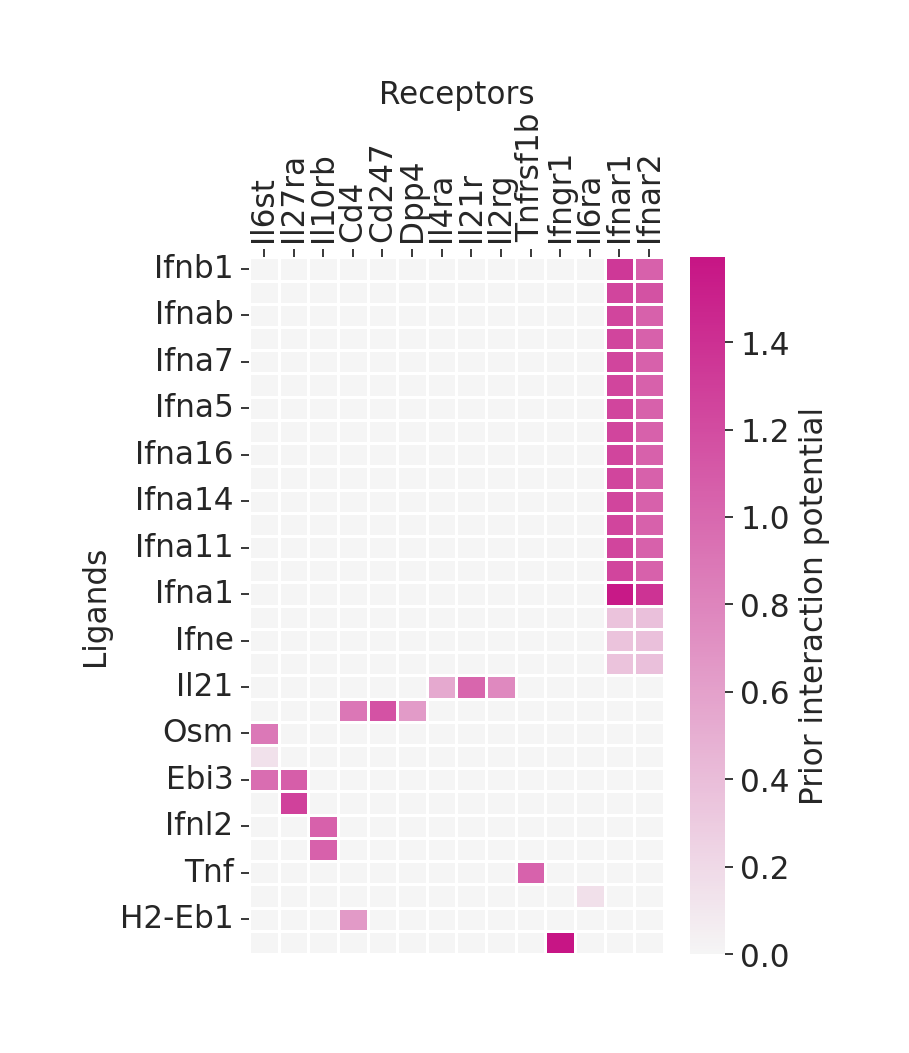

In [39]:
_ = nn.make_heatmap_ggplot(
    df_lr,
    y_name="Ligands",
    x_name="Receptors",
    color="mediumvioletred",
    legend_title="Prior interaction potential",
    figsize=(5, 6),
    show=True,
)

### 6. Sender-focused approach

To perform the sender-focused approach, we subset the ligand activities to only contain expressed ligands from the defined sender populations.

In [41]:
# Save sender-agnostic results
ligand_activities_all = ligand_activities.copy()
best_upstream_ligands_all = best_upstream_ligands.copy()

# Filter to sender-expressed ligands
ligand_activities = ligand_activities[
    ligand_activities["test_ligand"].isin(potential_ligands_focused)
]

best_upstream_ligands = (
    ligand_activities.nlargest(30, "aupr_corrected")["test_ligand"].unique().tolist()
)

In [42]:
# Sender-focused ligand activity heatmap
vis_ligand_aupr = (
    ligand_activities[ligand_activities["test_ligand"].isin(best_upstream_ligands)]
    .set_index("test_ligand")[["aupr_corrected"]]
    .sort_values("aupr_corrected")
)

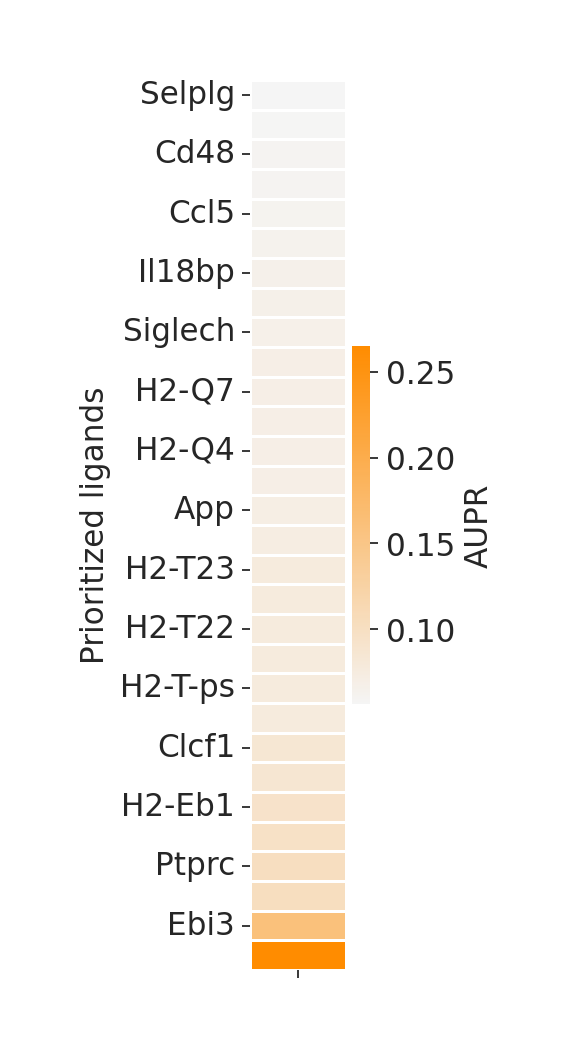

In [44]:
_ = nn.make_heatmap_ggplot(
    vis_ligand_aupr,
    y_name="Prioritized ligands",
    x_name="Ligand activity",
    legend_title="AUPR",
    color="darkorange",
    x_axis=False,
    figsize=(3, 6),
    show=True,
)

In [45]:
# Sender-focused: ligand-target heatmap
active_ligand_target_links_df = pd.concat(
    [
        nn.get_weighted_ligand_target_links(
            ligand_oi=lig,
            geneset=geneset_oi,
            ligand_target_matrix=ligand_target_matrix,
            n=100,
        )
        for lig in best_upstream_ligands
    ],
    ignore_index=True,
).dropna()

active_ligand_target_links = nn.prepare_ligand_target_visualization(
    ligand_target_df=active_ligand_target_links_df,
    ligand_target_matrix=ligand_target_matrix,
    cutoff=0.33,
)

order_ligands = [l for l in reversed(best_upstream_ligands) if l in active_ligand_target_links.colnames]
order_targets = [
    t for t in active_ligand_target_links_df["target"].unique()
    if t in active_ligand_target_links.rownames
]

df_full = pd.DataFrame(
    active_ligand_target_links,
    index=active_ligand_target_links.rownames,
    columns=active_ligand_target_links.colnames,
)
vis_ligand_target = df_full.loc[order_targets, order_ligands].T

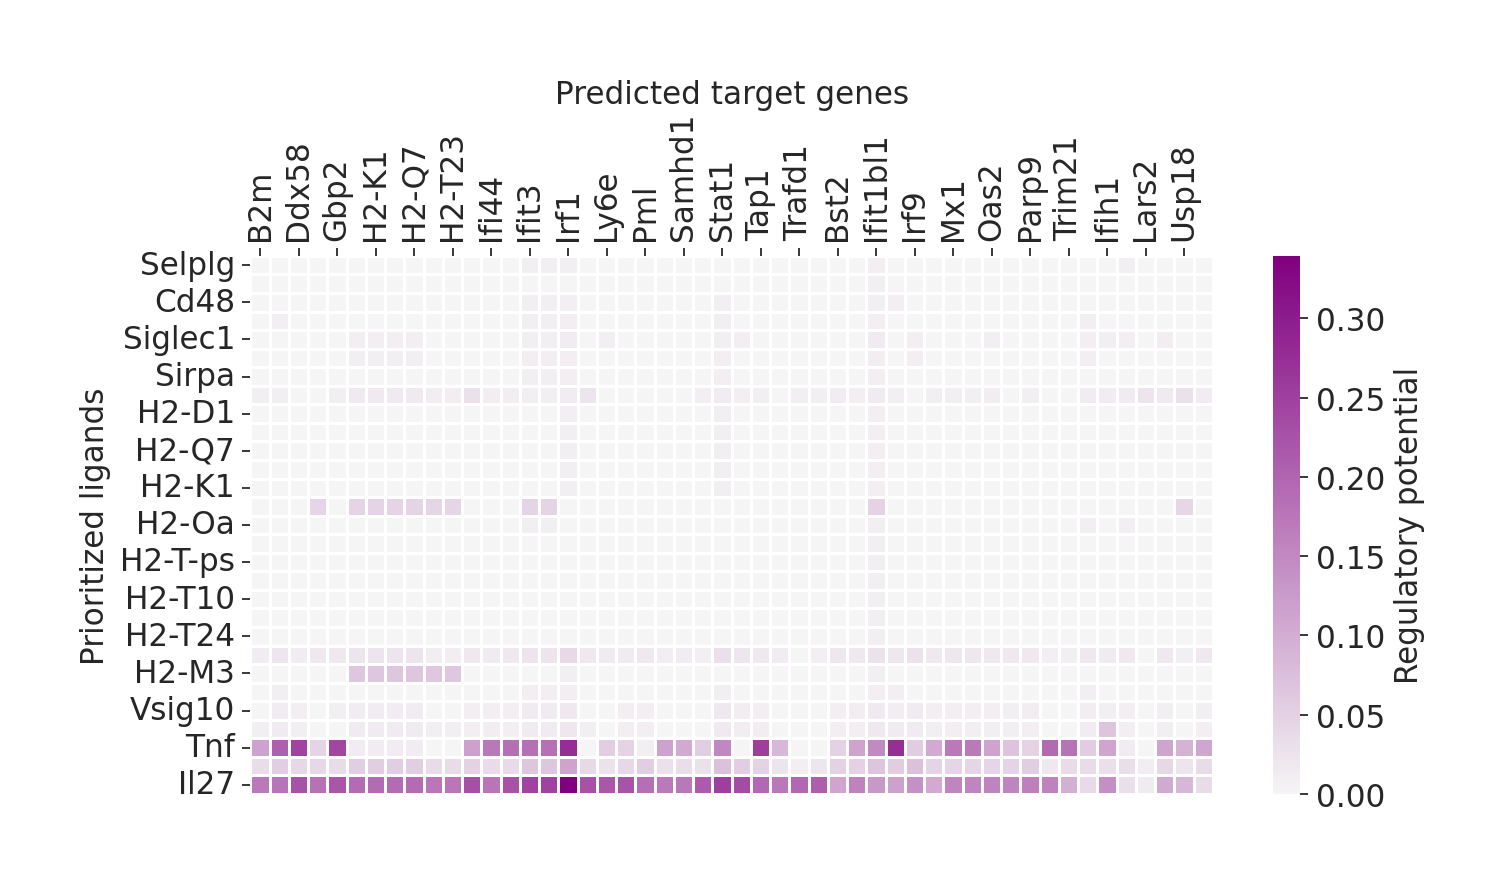

In [47]:
_ = nn.make_heatmap_ggplot(
    vis_ligand_target,
    y_name="Prioritized ligands",
    x_name="Predicted target genes",
    color="purple",
    legend_title="Regulatory potential",
    figsize=(9, 5),
    show=True,
)

In [48]:
# Sender-focused: ligand-receptor heatmap
ligand_receptor_links_df = nn.get_weighted_ligand_receptor_links(
    best_upstream_ligands, expressed_receptors, lr_network, weighted_networks["lr_sig"]
)

vis_ligand_receptor_network = nn.prepare_ligand_receptor_visualization(
    ligand_receptor_links_df, best_upstream_ligands, order_hclust="both"
)

df_lr = pd.DataFrame(
    vis_ligand_receptor_network,
    index=vis_ligand_receptor_network.rownames,
    columns=vis_ligand_receptor_network.colnames,
).T

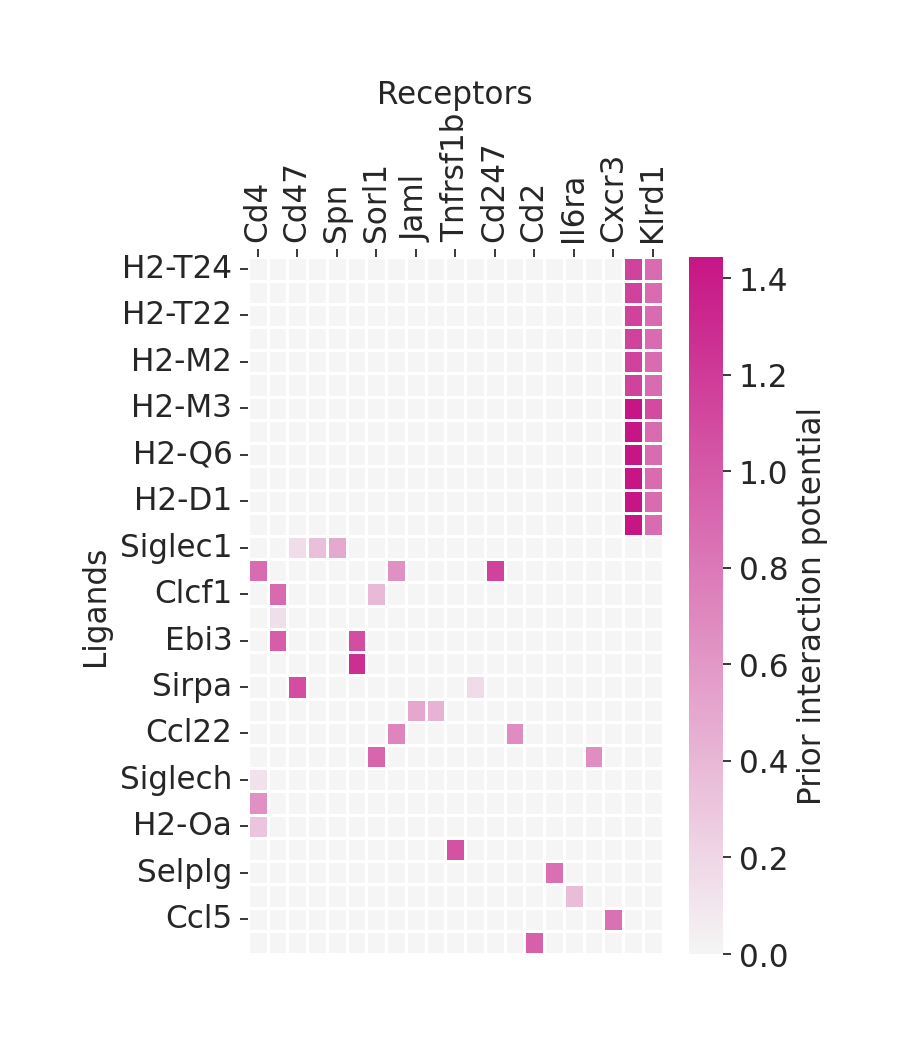

In [49]:
_ = nn.make_heatmap_ggplot(
    df_lr,
    y_name="Ligands",
    x_name="Receptors",
    color="mediumvioletred",
    legend_title="Prior interaction potential",
    figsize=(5, 6),
    show=True,
)

### Visualizing expression and log-fold change in sender cells

For the sender-focused approach, we can investigate which sender cell populations are potentially the true senders of these ligands. First, we check expression via a dot plot, then compute log-fold changes between conditions per sender cell type.

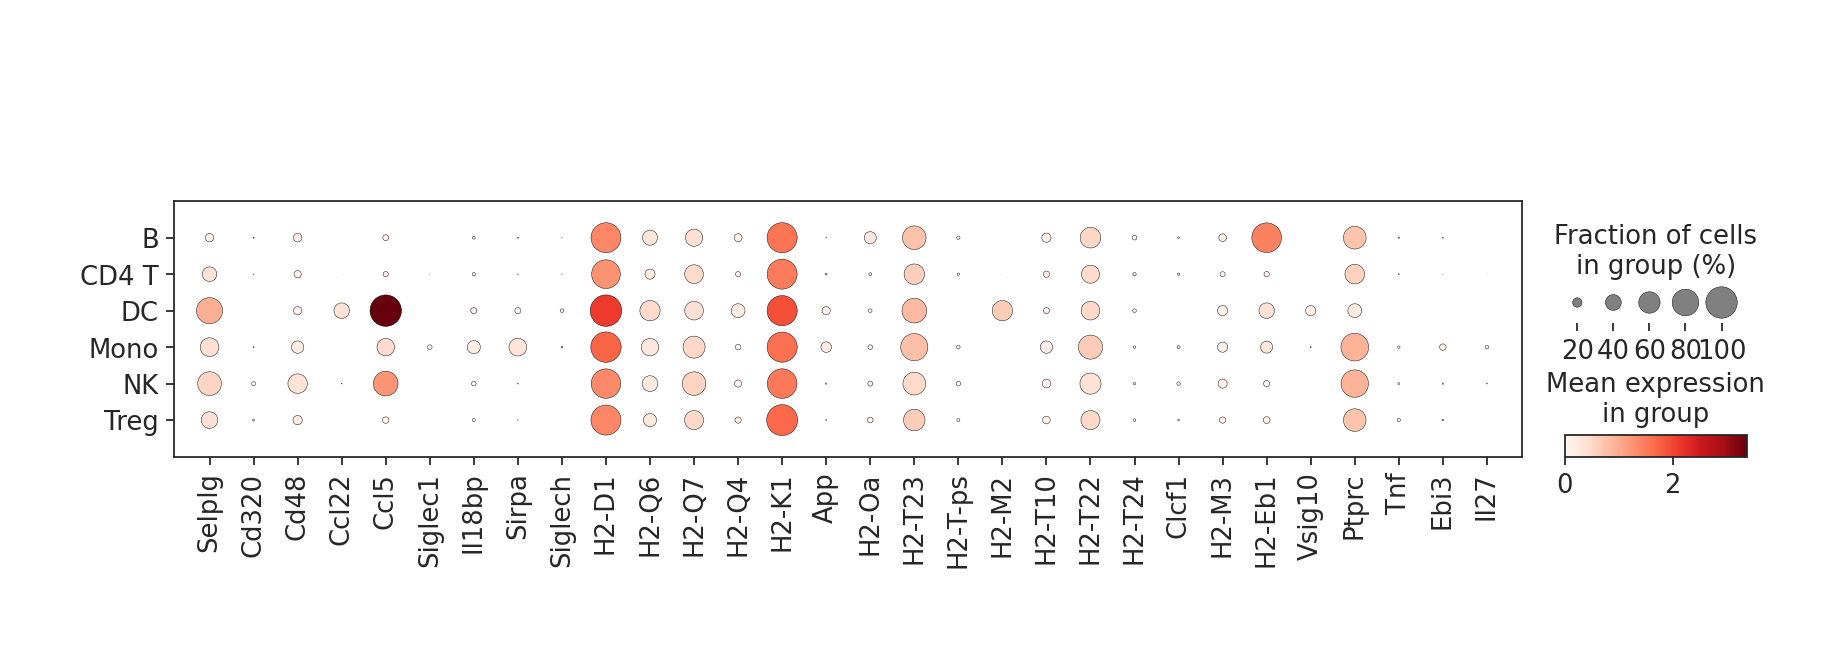

In [50]:
# Dotplot of top ligands in sender cell types
sender_mask = adata.obs["celltype"].isin(sender_celltypes)
sc.pl.dotplot(
    adata[sender_mask],
    var_names=list(reversed(best_upstream_ligands)),
    groupby="celltype",
)

In [51]:
# Compute log-fold change of ligands between conditions per sender cell type
vis_ligand_lfc = nn.get_lfc_celltype(
    adata,
    celltype_col="celltype",
    senders=sender_celltypes,
    condition_col="aggregate",
    condition_oi=condition_oi,
    condition_ref=condition_reference,
    ligands_oi=best_upstream_ligands,
)

# Prepare as matrix for heatmap
lfc_matrix = vis_ligand_lfc.set_index("gene")
lfc_matrix = lfc_matrix.reindex(list(reversed(best_upstream_ligands)))


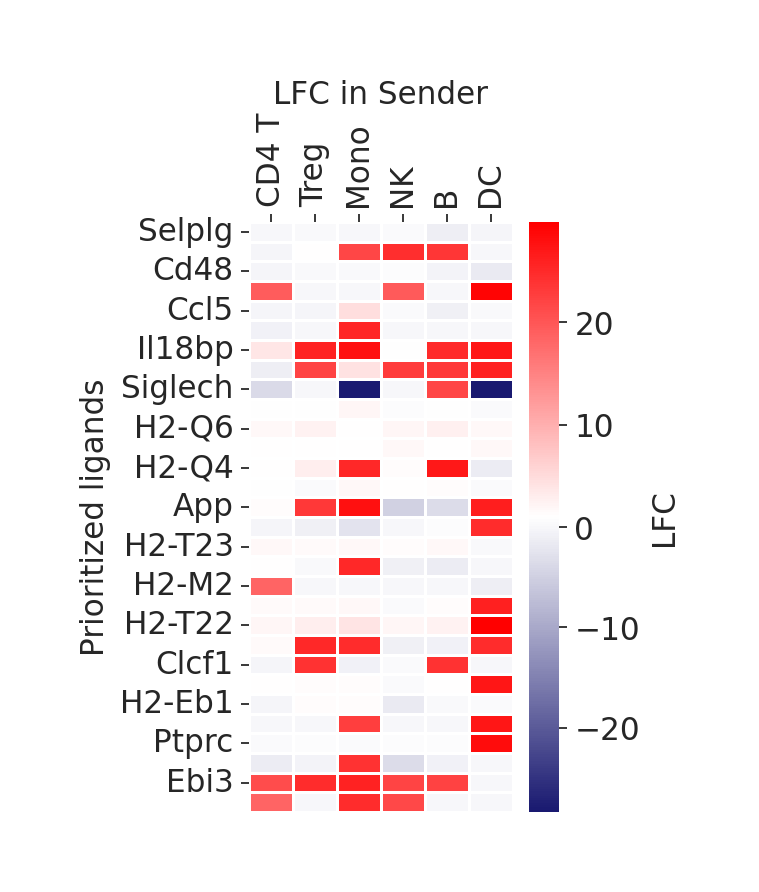

In [54]:
_ = nn.make_threecolor_heatmap_ggplot(
    lfc_matrix,
    y_name="Prioritized ligands",
    x_name="LFC in Sender",
    low_color="midnightblue",
    mid_color="white",
    mid=float(np.nanmedian(lfc_matrix.values)),
    high_color="red",
    legend_title="LFC",
    figsize=(4, 5),
    show=True,
)

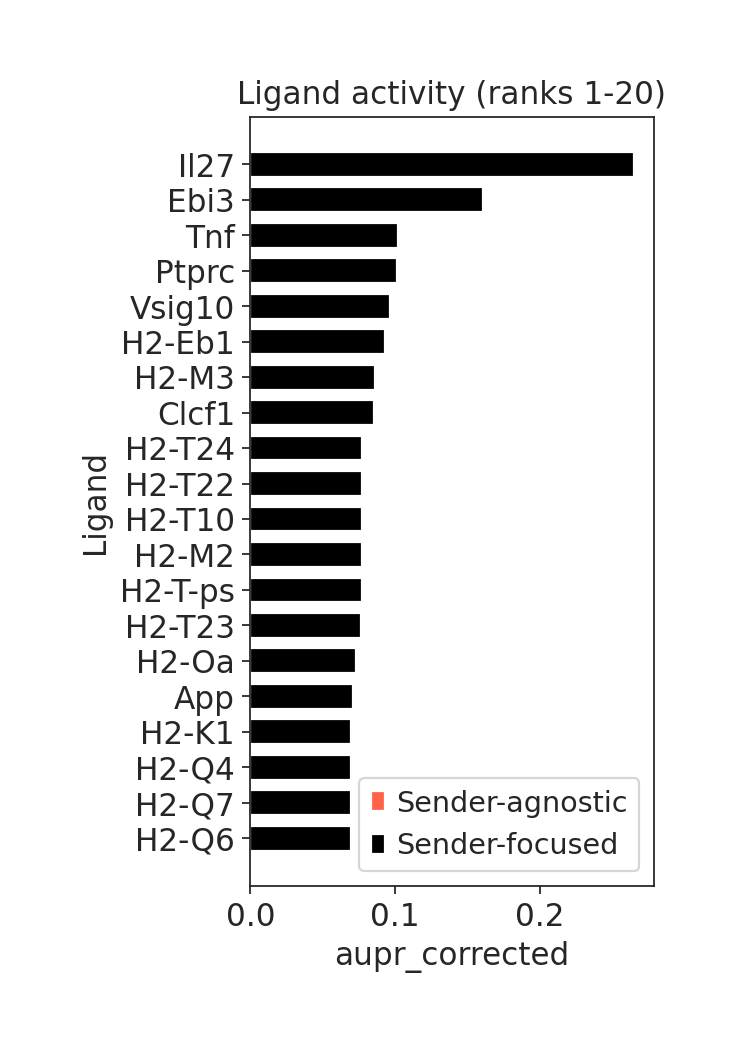

In [59]:
# Compare sender-agnostic and sender-focused rankings
_ = nn.make_line_plot(
    ligand_activities=ligand_activities_all,
    potential_ligands=potential_ligands_focused,
    show=True,
    figsize=(4, 6)
)

## Other follow-up analyses

- **Signaling paths**: Infer possible signaling paths between ligands and targets of interest (see `ligand_target_signaling_path` tutorial).
- **Target prediction evaluation**: Assess how well top-ranked ligands can predict the gene set of interest (see `target_prediction_evaluation_geneset` tutorial).
- **Circos plots**: Visualize ligand-target links between multiple interacting cells (see `circos` and `seurat_wrapper_circos` tutorials).